# CCQR on a toy heteroscedastic regression problem

This self-contained example generates synthetic data, selects **CCQR(d,w)** with the public `ccqr` API, and plots calibrated **90% prediction intervals**. Ordinary CQR is included as a reference using the same fitted quantile random forest (QRF) and the same calibration sample.

From the repository root, install the package and notebook dependencies:

```bash
python -m pip install -e ".[examples,notebook]"
python -m jupyterlab examples/toy_ccqr.ipynb
```

Then select **Restart Kernel and Run All Cells**. All random seeds and settings are fixed below. No external dataset, private helper, or research-project directory is needed. The saved outputs show one run; they are an API demonstration, not a repeated-simulation comparison.


In [1]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import platform

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from quantile_forest import RandomForestQuantileRegressor

from ccqr import ConformalLengthWeightedCQR, StandardCQR, select_ccqr

%matplotlib inline

SEED = 0
ALPHA = 0.10
N_PROPER, N_CALIBRATION, N_TEST = 1000, 1000, 5000
K = 5  # Cross-fitting folds, not the number of quantile pairs.
N_QUANTILES = 9
D_CANDIDATES = np.round(np.arange(0.0, 0.401, 0.05), 2)

print(f"Python {platform.python_version()} | ccqr {version('ccqr')}")


Python 3.12.14 | ccqr 0.4.0


## 1. Generate three independent samples

The one-dimensional data-generating process is

$$
X \sim \operatorname{Uniform}(-2,2),\qquad
Y = \mu(X) + \sigma(X)\varepsilon,\qquad
\varepsilon \sim N(0,1),\quad \varepsilon\perp X,
$$

with

$$
\mu(x)=\sin(\pi x)+0.5x,\qquad
\sigma(x)=0.25+0.25(x+2).
$$

The conditional noise standard deviation increases from 0.25 to 1.25. There is no added contamination. Independent random streams derived from seed 0 produce the samples below.

| Sample | Size | Role |
|---|---:|---|
| Proper training | 1,000 | Five-fold OOF selection of d and w; final QRF fit |
| Calibration | 1,000 | Final conformal correction for each method |
| Test | 5,000 | Coverage and mean interval length only |

The calibration and test observations do not enter model fitting or selection.


In [2]:
def conditional_mean(x):
    return np.sin(np.pi * x) + 0.5 * x


def conditional_scale(x):
    return 0.25 + 0.25 * (x + 2.0)


def generate_data(n, rng):
    x = rng.uniform(-2.0, 2.0, size=n)
    y = conditional_mean(x) + conditional_scale(x) * rng.standard_normal(n)
    return x[:, None], y


streams = np.random.SeedSequence(SEED).spawn(3)
X_proper, y_proper = generate_data(N_PROPER, np.random.default_rng(streams[0]))
X_calibration, y_calibration = generate_data(
    N_CALIBRATION, np.random.default_rng(streams[1])
)
X_test, y_test = generate_data(N_TEST, np.random.default_rng(streams[2]))

print(
    f"Proper training: {len(y_proper):,} | "
    f"Calibration: {len(y_calibration):,} | Test: {len(y_test):,}"
)


Proper training: 1,000 | Calibration: 1,000 | Test: 5,000


## 2. Select d and w using proper-training OOF predictions

The base learner uses **300 trees**, **minimum leaf size 10**, and **all features**. These hyperparameters are fixed. A single worker keeps this small example usable on machines with restricted multiprocessing.

`select_ccqr(..., selection="both")` fits five fold-specific forests and selects the bandwidth and shared convex pair weights using only proper-training out-of-fold predictions. The candidate bandwidths are 0, 0.05, ..., 0.40. A positive d uses nine pairs whose lower levels run from 0.05 to 0.05 + d and whose upper levels run from 0.95 to 0.95 - d. At d = 0 there is one pair, (0.05, 0.95).

The selector minimizes OOF conformalized mean interval length. Weight optimization uses the package defaults: prefix-uniform starts plus eight Dirichlet starts, with at most 300 iterations per start. Its OOF correction is a selection diagnostic, not the final calibration correction.


In [3]:
def model_factory(seed):
    return RandomForestQuantileRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        max_features=1.0,
        random_state=seed,
        n_jobs=1,
    )


started = perf_counter()
choice = select_ccqr(
    model_factory,
    X_proper,
    y_proper,
    D_CANDIDATES,
    selection="both",
    K=K,
    n_quantiles=N_QUANTILES,
    quantiles=(ALPHA / 2, 1 - ALPHA / 2),
    alpha=ALPHA,
    random_state=SEED,
    n_random_starts=8,
    maxiter=300,
)
selection_seconds = perf_counter() - started

print(f"Selected d: {choice['bandwidth']:.2f}")
print(f"OOF mean interval length: {choice['objective']:.4f}")
print(f"OOF selection time: {selection_seconds:.2f} seconds")

weight_rows = [
    "| Pair | Lower quantile | Upper quantile | Weight |",
    "|---:|---:|---:|---:|",
]
for j, (lower, upper, weight) in enumerate(
    zip(choice["lower_grid"], choice["upper_grid"], choice["weights"]), start=1
):
    weight_rows.append(f"| {j} | {lower:.4f} | {upper:.4f} | {weight:.4f} |")
display(Markdown("\n".join(weight_rows)))


Selected d: 0.20
OOF mean interval length: 2.4223
OOF selection time: 11.00 seconds


| Pair | Lower quantile | Upper quantile | Weight |
|---:|---:|---:|---:|
| 1 | 0.0500 | 0.9500 | 0.2345 |
| 2 | 0.0750 | 0.9250 | 0.1023 |
| 3 | 0.1000 | 0.9000 | 0.0000 |
| 4 | 0.1250 | 0.8750 | 0.0000 |
| 5 | 0.1500 | 0.8500 | 0.2921 |
| 6 | 0.1750 | 0.8250 | 0.1529 |
| 7 | 0.2000 | 0.8000 | 0.0935 |
| 8 | 0.2250 | 0.7750 | 0.0000 |
| 9 | 0.2500 | 0.7500 | 0.1247 |

## 3. Fit the final forest and calibrate both methods

After selection, fit a fresh QRF on all 1,000 proper-training observations. Both methods use this same fitted forest.

CQR starts from the 0.05 and 0.95 quantiles. CCQR starts from the weighted endpoints selected above. Each method then computes its own split-conformal correction from the same untouched calibration sample. No calibration observations are added to the final forest's training data.


In [4]:
started = perf_counter()
final_model = model_factory(SEED)
final_model.fit(X_proper, y_proper)

predictors = {
    "CQR": StandardCQR(final_model, alpha=ALPHA).calibrate(
        X_calibration, y_calibration
    ),
    "CCQR(d,w)": ConformalLengthWeightedCQR(
        final_model,
        lower_grid=choice["lower_grid"],
        upper_grid=choice["upper_grid"],
        weights=choice["weights"],
        alpha=ALPHA,
    ).calibrate(X_calibration, y_calibration),
}
fit_calibration_seconds = perf_counter() - started
print(f"Final fit and calibration: {fit_calibration_seconds:.2f} seconds")


Final fit and calibration: 0.48 seconds


## 4. Evaluate on the independent test sample

Coverage is the proportion of test responses inside the predicted intervals. Mean interval length is the average of $\max(U-L,0)$; an inverted interval represents the empty set. The relative length reduction is $100\{1-\overline L_{\mathrm{CCQR}}/\overline L_{\mathrm{CQR}}\}$, so a positive value means shorter CCQR intervals.

The conformal target is **90% marginal coverage** under exchangeability. It is not a guarantee of exactly 90% empirical coverage on every simulation draw or at every x. A single seed also need not show shorter CCQR intervals.


In [5]:
test_intervals = {}
metrics = {}
metric_rows = [
    "| Method | Test coverage | Mean interval length | Calibration correction |",
    "|---|---:|---:|---:|",
]
for name, predictor in predictors.items():
    intervals = predictor.predict(X_test)
    assert intervals.shape == (N_TEST, 2)
    assert np.isfinite(intervals).all()
    lower, upper = intervals.T
    coverage = np.mean((lower <= y_test) & (y_test <= upper))
    mean_length = np.mean(np.maximum(upper - lower, 0.0))
    test_intervals[name] = intervals
    metrics[name] = {"coverage": float(coverage), "mean_length": float(mean_length)}
    metric_rows.append(
        f"| {name} | {coverage:.2%} | {mean_length:.4f} | {predictor.qhat_:.4f} |"
    )

display(Markdown("\n".join(metric_rows)))
reduction_pct = 100 * (
    1 - metrics["CCQR(d,w)"]["mean_length"] / metrics["CQR"]["mean_length"]
)
print(f"CCQR mean length reduction relative to CQR: {reduction_pct:+.2f}%")


| Method | Test coverage | Mean interval length | Calibration correction |
|---|---:|---:|---:|
| CQR | 92.12% | 2.7796 | 0.2162 |
| CCQR(d,w) | 91.06% | 2.6596 | 0.5056 |

CCQR mean length reduction relative to CQR: +4.32%


## 5. Visualize the prediction intervals

Evaluate both predictors on the same increasing x grid. The shaded regions are calibrated prediction intervals, the solid dark curve is the QRF median, and the dashed curve is the true conditional mean. The same first 300 test observations appear in both panels; all 5,000 test observations enter the reported metrics.

The PNG is also saved as `toy_ccqr_intervals.png` in the kernel's working directory (normally this notebook's `examples/` directory).


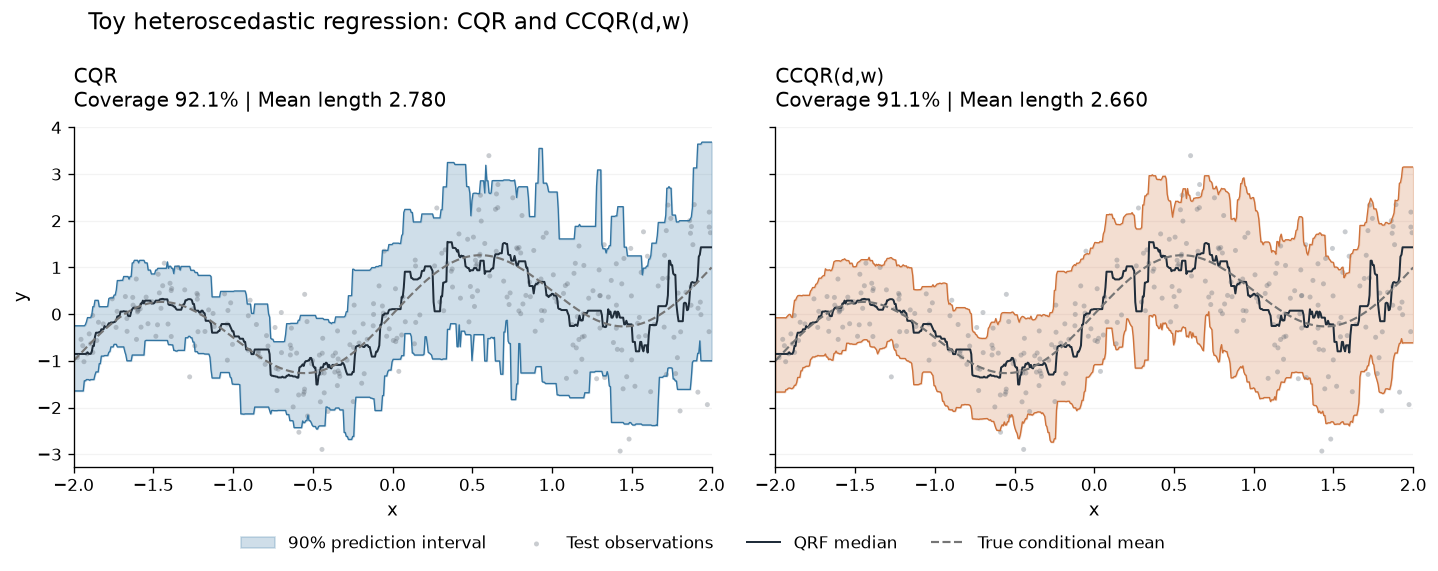

Saved: toy_ccqr_intervals.png


In [6]:
x_grid = np.linspace(-2.0, 2.0, 600)
X_grid = x_grid[:, None]
median_grid = np.asarray(
    final_model.predict(X_grid, quantiles=[0.5])
).reshape(-1)
grid_intervals = {
    name: predictor.predict(X_grid) for name, predictor in predictors.items()
}

colors = {"CQR": "#3274A1", "CCQR(d,w)": "#CE7139"}
with plt.rc_context({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "figure.dpi": 120,
}):
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True, sharey=True)
    for ax, (name, intervals) in zip(axes, grid_intervals.items()):
        lower, upper = intervals.T
        valid = lower <= upper
        ax.fill_between(
            x_grid, lower, upper, where=valid,
            color=colors[name], alpha=0.23, label="90% prediction interval",
        )
        ax.plot(x_grid, np.where(valid, lower, np.nan), color=colors[name], lw=0.8)
        ax.plot(x_grid, np.where(valid, upper, np.nan), color=colors[name], lw=0.8)
        ax.scatter(
            X_test[:300, 0], y_test[:300], s=9, color="#59636E",
            alpha=0.32, edgecolors="none", label="Test observations",
        )
        ax.plot(
            x_grid, median_grid, color="#202D3A", lw=1.2,
            label="QRF median",
        )
        ax.plot(
            x_grid, conditional_mean(x_grid), color="#757575",
            lw=1.3, linestyle="--", label="True conditional mean",
        )
        result = metrics[name]
        ax.set_title(
            f"{name}\nCoverage {result['coverage']:.1%} | "
            f"Mean length {result['mean_length']:.3f}",
            loc="left", pad=12,
        )
        ax.set_xlabel("x")
        ax.set_xlim(-2, 2)
        ax.grid(axis="y", alpha=0.15)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("y")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", ncol=4,
        frameon=False, bbox_to_anchor=(0.5, 0.015),
    )
    fig.suptitle(
        "Toy heteroscedastic regression: CQR and CCQR(d,w)",
        x=0.08, ha="left", fontsize=14,
    )
    fig.subplots_adjust(left=0.07, right=0.985, bottom=0.19, top=0.78, wspace=0.10)
    figure_path = Path("toy_ccqr_intervals.png")
    fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

print(f"Saved: {figure_path.name}")


## Other selection modes and reproducibility

The joint-selection workflow above can also be used with either of these choices:

```python
# Select d with uniform weights.
d_choice = select_ccqr(
    model_factory, X_proper, y_proper, D_CANDIDATES,
    selection="d", K=K, n_quantiles=N_QUANTILES, alpha=ALPHA, random_state=SEED,
)

# Select w at the fixed bandwidth d = 0.4.
w_choice = select_ccqr(
    model_factory, X_proper, y_proper, D_CANDIDATES,
    selection="w", d=0.4, K=K, n_quantiles=N_QUANTILES,
    alpha=ALPHA, random_state=SEED,
)
```

Each call performs its own cross-fitting; these alternatives are shown for reference and are not run in this notebook. In either case, pass the returned grids and weights to `ConformalLengthWeightedCQR` and calibrate on the held-out calibration sample, as above.

The data, forest seeds, fold assignment, and optimizer seed are fixed. Timing depends on the machine, and package versions can change numerical optimization results. The environment used for the saved outputs is recorded below.


In [7]:
print(f"Python: {platform.python_version()}")
for package in ("ccqr", "numpy", "scipy", "scikit-learn", "quantile-forest", "matplotlib"):
    print(f"{package}: {version(package)}")


Python: 3.12.14
ccqr: 0.4.0
numpy: 2.5.3
scipy: 1.18.1
scikit-learn: 1.9.1
quantile-forest: 1.4.2
matplotlib: 3.11.2
